In [1]:
%matplotlib inline

# MLP

Uma das formas mais tradicionais de redes neurais é a MLP, ou Multilayer Perceptron. 
A MLP é um algoritmo de aprendizado supervisionado que aprende uma função que relaciona entradas e saídas através do seu treinamento em um conjunto de dados.

Tipicamente, uma MLP é formada por:
- uma camada de entrada, que corresponde aos M atributos a serem usados para a classificação
- uma camada de saída, que possui um neurônio para cada uma das N classes em que a amostra de atributos será classificada
- uma ou mais camadas ocultas de neurônios, responsáveis por tornar a MLP um classificador não linear



## A instanciação de uma MLP

Para criarmos uma MLP no `scikit-learn` usamos a classe `MLPClassifier` do pacote `sklearn.neural_network` através do código:
```python
from sklearn.neural_network import MLPClassifier
```
A instanciação de um objeto representando a MLP depende da definição de **hiperparâmetros**, ou seja parâmetros da rede que não serão aprendidos durante a fase de treinamento. Até agora, os hiperparâmetros que aprendemos são:

### 1. Número de camadas ocultas
Indica quandas camadas ocultas serão usadas na rede neural. Há provas matemáticas de que uma rede do tipo MLP com função de ativação sigmóide pode aproximar qualquer função contínua com apenas uma única camada oculta de neurônios, porém para funções descontínuas, duas são necessárias (ver livro do Russel, pág. 720). Na prática, para dados simples, não precisamos de mais do que uma camada, e partimos para a decisão do número de neurônios nessa camada. O inconveniente dessa abordagem é que o número de neurônios necessários para realizar a classificação corretamente pode ter que crescer muito dependendo da complexidade dos dados. 

### 2. Número de neurônios por camada oculta
No caso de escolhermos usar apenas uma camada oculta, é preciso escolher o número de neurônios a ser empregado.
Há algumas "receitas de bolo" para essa decisão, porém a melhor forma de determinar esse parâmetro é realizar diversos testes com os dados de treinamento, através da *validação cruzada*. Uma dessas receitas de bolo indica que o número de neurônios da camada oculta seja o dobro do número de elementos de entrada mais um, que nós podemos usar como ponto de partida para a realização de testes.

### 3. Função de ativação $f(a)$
A função de ativação processa a entrada líquida do neurônio, resultante do somatório das entradas multiplicadas pelos pesos.
Para a tarefa de classificação, as funções de ativação mais comumente empregadas são:
- Logística ou sigmóide: $f(a)=\frac{1}{1+e^{-a}}$
<img width="400px" src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/1920px-Logistic-curve.svg.png"/>
- Tangente hiperbólica: $f(a) = tanh(a) = \frac{e^a - e^{-a}}{e^a + e^{-a}}$
<img width="400px" src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/87/Hyperbolic_Tangent.svg/250px-Hyperbolic_Tangent.svg.png">

- Linear retificada (ReLU): $f(a) = \begin{cases} a, & \mbox{se } a>=0 \\ 0, & \mbox{caso contrário } \end{cases}$
<img width="400px" src="http://ml4a.github.io/images/figures/relu.png">


Há também parâmetros relacionados ao processo de treinamento:
- Taxa de aprendizado $\eta$: valor maior do que zero que representa a velocidade em que ocorre o aprendizado
- *Batch size*: número de amostras a serem usadas a cada atualização de pesos
- Algoritmo de otimização: embora o algoritmo Backpropagation e suas variações seja o mais empregado, há outros algoritmos disponíveis para o trienamento. Aqui vamos trabalhar com o Backpropagation tradicional.
- Número de épocas: determina quantas épocas, ou seja, quantas vezes cada amostra de entrada será utilizada, mesmo que o algoritmo de otimização não tenha encontrado um resultado confiável

Dessa forma, a instanciação da nossa rede MLP fica:

In [2]:
from sklearn.neural_network import MLPClassifier
# Definição dos hiperparâmetros
# Função de ativação: pode ser uma dentre: {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, default ‘relu’
activation = 'logistic' 
# Tamanhos das camadas ocultas
hidden_layer_sizes = [100] # Apenas uma camada com cem neurônios
# Algoritmo de otimização: pode ser um dentre {‘lbfgs’, ‘sgd’, ‘adam’}, default ‘adam’
solver = 'sgd' #Stochastic Gradient Descent
# Valor da taxa de aprendizado, default 0.001
learning_rate =  0.03
# Batch size, default é 'auto', ou seja, min(200, n_samples)
batch_size=20
# Número máximo de épocas, default 200
max_iter = 500
mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                    activation=activation, solver=solver,
                    learning_rate_init=learning_rate,
                    batch_size=batch_size,
                    max_iter=max_iter,
                    random_state=42) # semente fixa: o resultado se repete a cada execucao

# Classificando Imagens com a MLP

Na classificação de padrões de imagens, nosso objetivo é classificar o conteúdo de imagens digitais. Por exemplo, podemos segmentar os caracteres na imagem de um documento, e, para cada imagem de caractere, identificar qual é a letra ou dígito correspondente. Outro exemplo é identificar qual animal está presente na imagem (*cachorro*, *gato* ou *papagaio*, por exemplo).


## 1. Gerando o vetor de atributos

Para classificar o conteúdo de imagens digitais, uma abordagem muito comum é o uso dos seus próprios pixels como atributos. Assim, se uma imagem tem tamanho 100x100 pixels, terermos um vetor de atributos de 10.000 posições!
- Vantagem: ganhamos flexibilidade no processo de classificação, já que não precisamos nos preocupar com a especificação de atributos específicos
- Desvantagem: grande número de atributos, torna o treinamento muito lento e pode inclusive não finalizar em tempo hábil 

Assim vamos definir a função `gera_vetor(w, h, arq)` que toma um arquivo de imagem, faz um preprocessamento e gera o vetor de atributos. Uma vez que o vetor de atributos deve semrpe ter o mesmo tamanho, a imagem é reescalonada para `h` linhas (o que corresponde à altura, ou * **h**eight*) e `w` colunas (o que corresponde à sua largura, ou * **w**idth*) 


In [3]:
import cv2
import numpy as np

def gera_vetor(w, h, arq):
    
   #w: largura desejada para a imagem
    #h: altura desejada para a imagem
    #arq: Caminho do arquivo de imagem
    #retorno: array com o vetor de atributos, de tamanho w*h
    
    #arq = ''
    # Ler imagem como tons de cinza
    img = cv2.imread(arq, cv2.IMREAD_GRAYSCALE)
    # Pré-processamento: 
    # 1. Passa o filtro da mediana
    # 2. gera imagem da magnitude do gradiente
    # 3. Faz a média ponderada da imagem com o resutado da magnitude do gradiente
    img = cv2.medianBlur(img, 3)
    # O tipo de imagem CV_16 comporta pixels de 16bits com valores positivos e negativos
    sobelx = cv2.Sobel(img, cv2.CV_16S, 1, 0)
    sobely = cv2.Sobel(img, cv2.CV_16S, 0, 1)
    # Retorna ao tipo original de 8 bits unsigned (0 a 255)
    mag_grad = cv2.add(np.abs(sobelx), np.abs(sobely), dtype=cv2.CV_8U)
    img = cv2.addWeighted(img, 0.7, mag_grad, 0.3, gamma=0)
    
    #Redimensionando a imagem
    img = cv2.resize(img,(w, h))
    
    # Transforma a imagem img em um array unidimensional e retorna
    
    return img.ravel()

## 2. Criando a matriz de dados de treinamento e de teste

Para usar os algoritmos de classificação de padrões é necessário transformar as amostras de vetor de atributos em linhas da matriz de treinamento.

As imagens representativas das diferentes classes estão armazenadas em diretórios homônimos (`NORMAL` e `PNEUMONIA`), dentro de dois conjuntos já separados: `train/` e `test/`. Como a mesma leitura serve para os dois, ela virou a função `carrega_pasta`.

O conjunto `test/` é carregado agora, mas **só será usado no final** — ele não participa do treino, nem do cálculo da média/desvio, nem do ajuste do PCA.

In [4]:
import os
import numpy as np
from pathlib import Path
import cv2

# Pasta raiz do dataset, ja separado em treino e teste
base = '/Users/icaroamerico/Documents/imagens_fase_1_pos_fiap'

# Tamanho para o qual toda imagem e reescalonada.
# Com 500x500 sao 250.000 atributos por imagem: a matriz de treino viraria ~10 GB
# em float64 na hora da normalizacao e nao cabe na memoria desta maquina.
# Com 64x64 sao 4.096 atributos e o dataset inteiro roda em menos de 1 GB.
LARGURA = ALTURA = 64

def carrega_pasta(pasta):

    #pasta: caminho de um conjunto (train ou test), com um subdiretorio por classe
    #retorno: matriz de atributos (uma linha por imagem) e array de classes

    X = []
    y = []
    for classe in sorted(os.listdir(pasta)):
        dir_classe = os.path.join(pasta, classe)
        if not os.path.isdir(dir_classe):
            continue
        for file in sorted(os.listdir(dir_classe)):
            # Ignora .DS_Store e qualquer coisa que nao seja imagem:
            # cv2.imread devolveria None e o pre-processamento quebraria
            if not file.lower().endswith('.jpeg'):
                continue
            X.append(gera_vetor(LARGURA, ALTURA, os.path.join(dir_classe, file)))
            # O alvo e o NOME da classe ('NORMAL'/'PNEUMONIA'), nao o caminho.
            # Se guardassemos o caminho, treino e teste teriam rotulos diferentes
            # ('.../train/NORMAL' vs '.../test/NORMAL') e a comparacao final daria
            # 100% de erro sem levantar erro nenhum.
            y.append(classe)
    return np.array(X), np.array(y)

treinamento, alvos = carrega_pasta(os.path.join(base, 'train'))
teste, alvos_teste = carrega_pasta(os.path.join(base, 'test'))

print('treino:', treinamento.shape, alvos.shape)
print('teste: ', teste.shape, alvos_teste.shape)
for conj, y in (('treino', alvos), ('teste', alvos_teste)):
    valores, contagens = np.unique(y, return_counts=True)
    print(conj, dict(zip(valores, contagens)))

treino: (5232, 4096) (5232,)
teste:  (624, 4096) (624,)
treino {np.str_('NORMAL'): np.int64(1349), np.str_('PNEUMONIA'): np.int64(3883)}
teste {np.str_('NORMAL'): np.int64(234), np.str_('PNEUMONIA'): np.int64(390)}


## 3. Separando as amostras de treinamento e validação

Para validar o resultado da classificação temos que reservar algumas amostras, sem usá-las no treinamento da rede, e comparar a previsão com a classe real.

Essa separação vem **antes** da normalização e do PCA de propósito: as amostras de validação não podem influenciar nem a média/desvio nem as componentes principais, senão elas deixam de ser dados "não vistos".

In [5]:
# 3. Separando as amostras de treinamento e validacao
frac_validacao = 0.2 # Separamos 20% para a validacao
# Primeiro embaralhamos os indices da matriz
import numpy.random as random
random.seed(42) # semente fixa: a mesma divisao a cada execucao
indices = random.permutation(treinamento.shape[0])

# ... depois separamos em porcao de treinamento e validacao
import math
icut = math.floor(frac_validacao * indices.shape[0])
indices_treino = indices[icut:]
indices_valid = indices[:icut]

print('treino:', indices_treino.shape[0],
      '| validacao:', indices_valid.shape[0],
      '| teste:', teste.shape[0])

treino: 4186 | validacao: 1046 | teste: 624


## 4. Normalizando e reduzindo a dimensionalidade

Um grande número de atributos pode atrapalhar o treinamento de classificadores, em especial a MLP. Para melhorar o desempenho, vamos normalizar os dados e reduzir a dimensionalidade com PCA - *Principal Component Analysis*.

O ponto central aqui: a média, o desvio e as componentes principais são calculados **apenas sobre a porção de treino**. Depois a *mesma* transformação é aplicada à validação e ao teste, com `transform` e nunca com `fit_transform`. É isso que garante que os três conjuntos vivam no mesmo espaço de atributos sem vazar informação.

In [6]:
# Normalizando os dados
# A media e o desvio saem SOMENTE da porcao de treino. Calcula-los sobre a matriz
# inteira deixaria a validacao influenciar a normalizacao -- vazamento de dados,
# que infla artificialmente o resultado.
media = treinamento[indices_treino].mean(axis=0)
desvio = treinamento[indices_treino].std(axis=0)
# Pixels constantes (bordas pretas) teriam desvio zero -> divisao por zero -> NaN
desvio[desvio == 0] = 1

treinamento_norm = (treinamento - media)/desvio
teste_norm = (teste - media)/desvio

#Reduzindo a dimensionalidade
from sklearn.decomposition import PCA
# Instancia o modelo PCA de forma que 85% da variabilidade de dados seja mantida
pca = PCA(.85)
# Ajusta as componentes principais so na porcao de treino...
pca.fit(treinamento_norm[indices_treino])
# ...e aplica a MESMA transformacao nos demais conjuntos (transform, nao fit_transform)
treinamento_pca = pca.transform(treinamento_norm)
teste_pca = pca.transform(teste_norm)

# Verificando o novo numero de atributos
print("Novo numero de atributos: ", treinamento_pca.shape[1])

Novo numero de atributos:  140


## 5. Treinando e executando a rede neural criada

In [7]:
# 4. Treinar o classificador MLP instanciado anteriormente, seprando as entradas e saídas 
mlp.fit(treinamento_pca[indices_treino,:], alvos[indices_treino])

,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",20
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.03
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",[100]
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


Uma observação sobre a sintaxe dos classificadores do `scikit-learn`
- O método fit(X,Y) recebe uma matriz ou dataframe X onde cada linha é uma amostra de aprendizado, e um array Y contendo as saídas esperadas do classificador, seja na forma de texto ou de inteiros
- O método predict(X) recebe uma matriz ou dataframe X onde cada linha é uma amostra de teste, retornando um array de classes

In [8]:
# 5. Executar o classificador nas amostras de validação
classes_valid = mlp.predict(treinamento_pca[indices_valid,:])

#Cálculo do erro
erro = np.sum(classes_valid != alvos[indices_valid])/indices_valid.shape[0]
print("Erro médio de classificação: ", erro)

Erro médio de classificação:  0.030592734225621414


# Fim do treinamento — início dos testes

Tudo acima usou somente a pasta `train/`: a rede foi ajustada em 80% dela e o erro reportado é de **validação**, medido nos 20% restantes. Como esses 20% orientaram as escolhas de hiperparâmetro, esse número já não é uma estimativa imparcial.

Daqui para baixo entra a pasta `test/`, que não foi tocada em nenhuma etapa anterior — nem no `fit` da MLP, nem no cálculo da média/desvio, nem no ajuste do PCA. É este resultado que mede a generalização de verdade.

In [9]:
# 6. Executando o classificador nas amostras de TESTE (nunca vistas)
classes_teste = mlp.predict(teste_pca)

erro_teste = np.sum(classes_teste != alvos_teste)/alvos_teste.shape[0]
print("Erro medio de classificacao (teste): ", round(erro_teste, 4))

# Linha de base: e se o classificador chutasse SEMPRE a classe mais frequente?
# Em dados desbalanceados a taxa de acerto sozinha engana, entao o resultado do
# modelo so significa alguma coisa se for melhor do que este chute.
valores, contagens = np.unique(alvos_teste, return_counts=True)
classe_maioria = valores[contagens.argmax()]
erro_base = 1 - contagens.max()/alvos_teste.shape[0]
print("Linha de base (sempre '{}'): {}".format(classe_maioria, round(erro_base, 4)))

Erro medio de classificacao (teste):  0.2308
Linha de base (sempre 'PNEUMONIA'): 0.375


## Matriz de confusão

O erro médio resume tudo em um número só e esconde *que tipo* de engano o modelo comete. A matriz de confusão mostra o que importa aqui: quantos pacientes com pneumonia foram classificados como normais.

Se uma linha inteira ficar vazia, o classificador degenerou — está sempre respondendo a mesma classe — e a taxa de acerto não significa nada, por melhor que pareça.

Matriz de confusao (linha = classe real, coluna = prevista)
rotulos: [np.str_('NORMAL'), np.str_('PNEUMONIA')]
[[ 95 139]
 [  5 385]]

              precision    recall  f1-score   support

      NORMAL       0.95      0.41      0.57       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.71       624
weighted avg       0.82      0.77      0.74       624



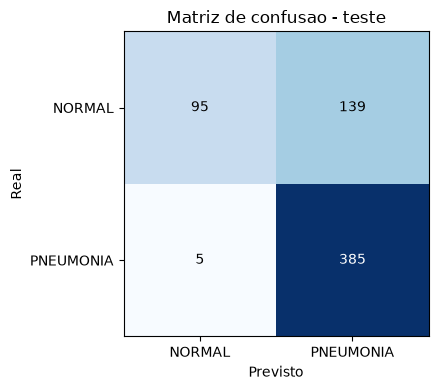

In [10]:
# Matriz de confusao e metricas por classe
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

rotulos = np.unique(alvos)
mc = confusion_matrix(alvos_teste, classes_teste, labels=rotulos)

print('Matriz de confusao (linha = classe real, coluna = prevista)')
print('rotulos:', list(rotulos))
print(mc, end='\n\n')
print(classification_report(alvos_teste, classes_teste, labels=rotulos))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(mc, cmap='Blues')
ax.set_xticks(range(len(rotulos))); ax.set_xticklabels(rotulos)
ax.set_yticks(range(len(rotulos))); ax.set_yticklabels(rotulos)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusao - teste')
for i in range(mc.shape[0]):
    for j in range(mc.shape[1]):
        ax.text(j, i, mc[i, j], ha='center', va='center',
                color='white' if mc[i, j] > mc.max()/2 else 'black')
plt.tight_layout()
plt.show()